IPL 2022 Capstone Project

The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.


These are some of the important columns that we'll focus on for meaningful insights in this project.


column names: Variable Type


date : string
venue : string
stage : string
team1 : string
team2 : string
toss_winner : string
toss_decision : string
first_ings_score : integer
second_ings_score : integer
match_winner : string
won_by : string
margin : integer
player_of_the_match : string
top_scorer : string
highscore : integer
best_bowling : string
best_bowling_fgure : string
gure : string

Load libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df =pd.read_csv('IPL.csv')
df.head()



,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [5]:
# Check the size of rows and columns of the dataset
print(f"the number of rows are {df.shape[0]} and the number of column are {df.shape[1]}")

the number of rows are 74 and the number of column are 20


In [7]:
# Now let's see how many columns have null values in total.
df.isnull().sum()
 

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Now, Here comes some Basic Questions

Which team won the most matches?

Text(0.5, 1.0, 'Most match wins by teams')

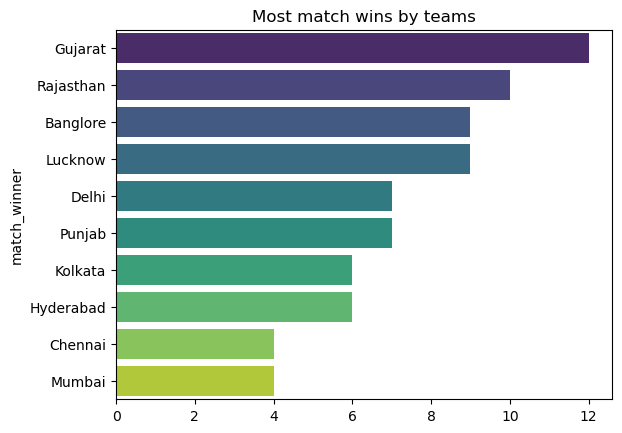

In [23]:
match_wins= df['match_winner'].value_counts()
sns.barplot(y=match_wins.index, x=match_wins.values,palette='viridis')
plt.title("Most match wins by teams")

Text(0, 0.5, 'no of time choses')

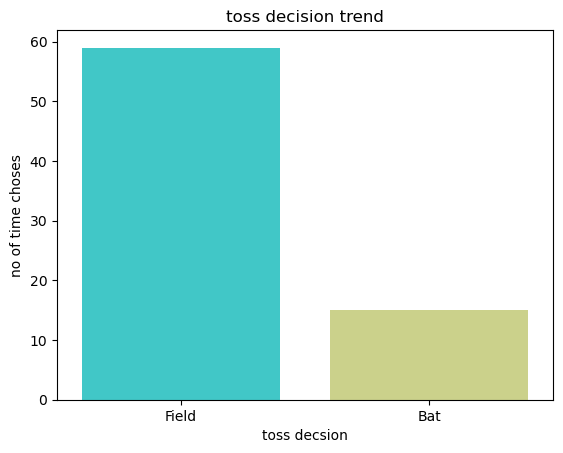

In [36]:
#toss decison trends
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title("toss decision trend")
plt.xlabel('toss decsion')
plt.ylabel('no of time choses')

In [39]:
#toss winner vs match winner
count =df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

<Axes: xlabel='won_by', ylabel='count'>

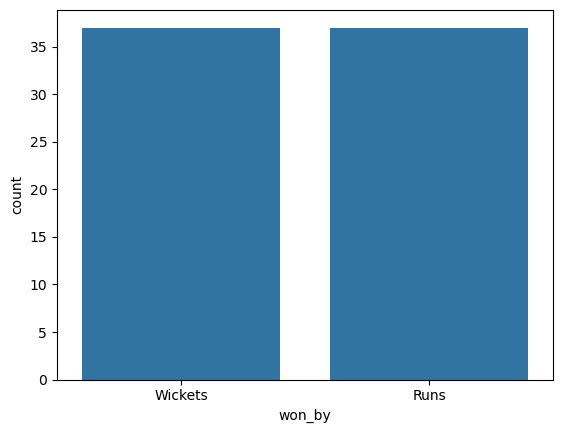

In [42]:
#how do tems win? (runs or wickets)
sns.countplot(x= df['won_by']) 

<Axes: ylabel='player_of_the_match'>

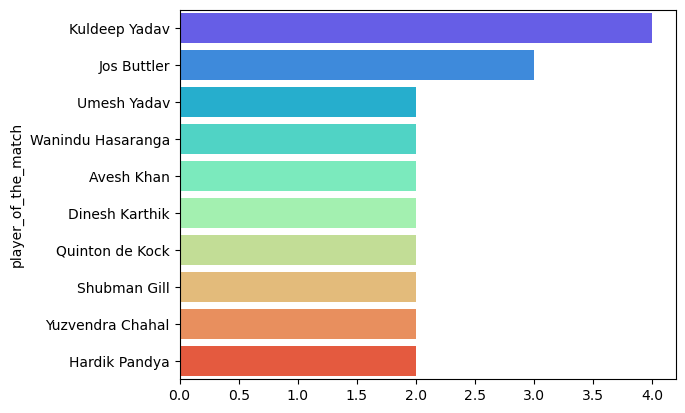

In [52]:
# most player of the match
counts =df['player_of_the_match'].value_counts().head(10)
counts
sns.barplot(x=counts.values,y=counts.index, palette="rainbow") 

In [ ]:
#top two scorrer
df['top_scorer'].value_counts().head(2)


top_scorer
Jos Buttler        7
Quinton de Kock    5
Name: count, dtype: int64

<Axes: ylabel='top_scorer'>

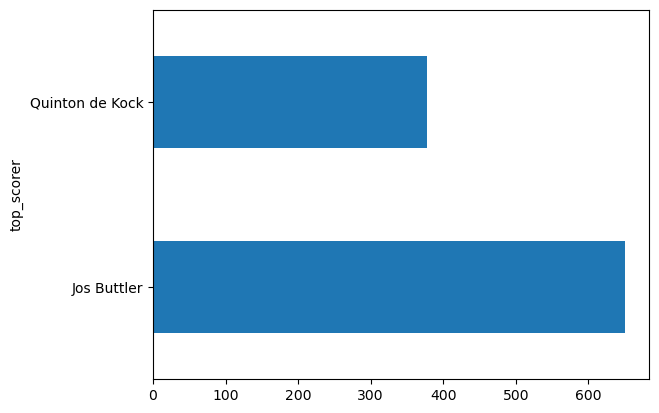

In [58]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high.plot(kind='barh')

<Axes: ylabel='best_bowling'>

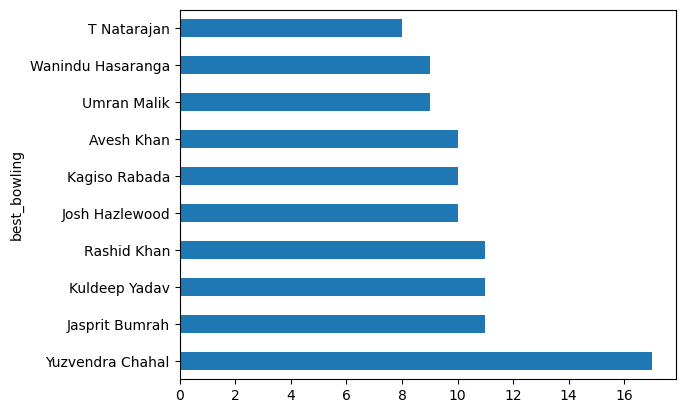

In [74]:
#top 10 bolwing figure
df["highest_wickets"] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df["highest_wickets"] = df["highest_wickets"].astype(int)
top_bowlers= df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')


<Axes: ylabel='venue'>

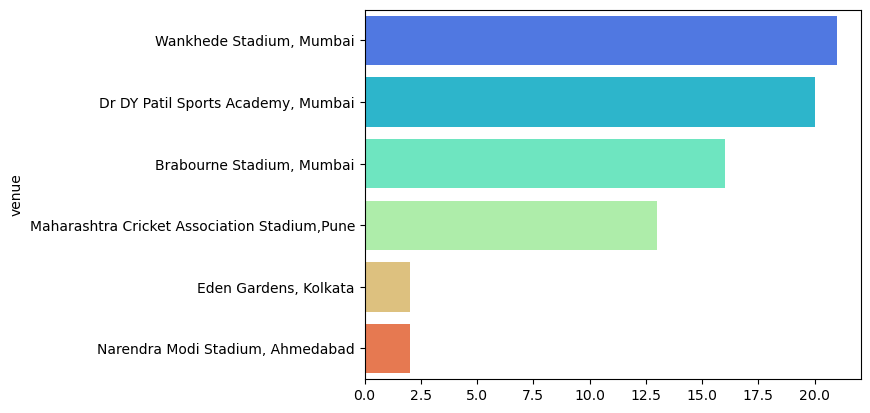

In [83]:
#most matches played by venue
match = df['venue'].value_counts()
# match.plot(kind='barh')
sns.barplot(y=match.index, x=match.values,palette='rainbow')

In [85]:
#who win the highest margin by runs?
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


In [95]:
#which player had the highest individual score?

df[df['highscore'] ==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [98]:
#which bowler had the best bowling figures?
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
